<a href="https://colab.research.google.com/github/Oalatorre77/C6_SC3_Octavio_Alatorre/blob/main/DS_C6_SC_4_Octavio_Alatorre_vf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto | Optimizar un modelo para predecir las cancelaciones en reservaciones hoteleras

## Objetivo
Producir un modelo de clasificación optimizado que ayude estimar las probabilidades de cancelación de reservaciones hoteleras.

## Objetivos específicos
- Producir un flujo de trabajo para un modelo de clasificación con técnicas estadísticas y de visualización para reducir el error de clasificación.
- Reportar el error de clasificación con el conjunto de prueba.
- Generar un CSV con tres columnas utilizando el conjunto de prueba: el id de la reservación, la probabilidad de cancelación y la clasificación de cancelación (0 ó 1)
- Justificar las decisiones de modelación para obtener el mejor modelo.

In [35]:
# Primero cargo las librerías que voy a necesitar en casi todo el reto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_fscore_support
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)


## Construir un flujo de trabajo para un problema de clasificación binaria que consideren los siguientes aspectos.

In [36]:
# Aquí leo el archivo con la ruta exacta

ruta = '/content/sample_data/hotels.csv'
df = pd.read_csv(ruta)

# Aquí reviso el tamaño y una muestra para empezar a entender los datos
print('Dimensión del dataset:', df.shape)
display(df.head())

Dimensión del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [37]:
# Aquí hago una revisión sencilla de tipos de datos y valores faltantes

display(df.info())

faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

print('Columnas con valores faltantes:')
display(faltantes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

Columnas con valores faltantes:


,0
company,112593
agent,16340
country,488
children,4


In [5]:
# Aquí reviso si hay duplicados porque no quiero modelar con registros repetidos sin saberlo

duplicados = df.duplicated().sum()
print('Número de filas duplicadas:', duplicados)

Número de filas duplicadas: 31994


In [50]:
# El dataset no trae un id de reservación, así que yo creo uno
# Este id lo voy a usar solo para la entrega final del CSV

df['reservation_id'] = np.arange(1, len(df)+1)

df[['reservation_id','is_canceled']].head()

,reservation_id,is_canceled
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## Detectar si hay un problema de desbalance en los datos y a partir de aquí actuar acorde al resultado.

In [51]:
# Aquí defino la variable objetivo del modelo

target_col = 'is_canceled'

conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True)*100

print(conteo)
print(porcentaje.round(2))

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


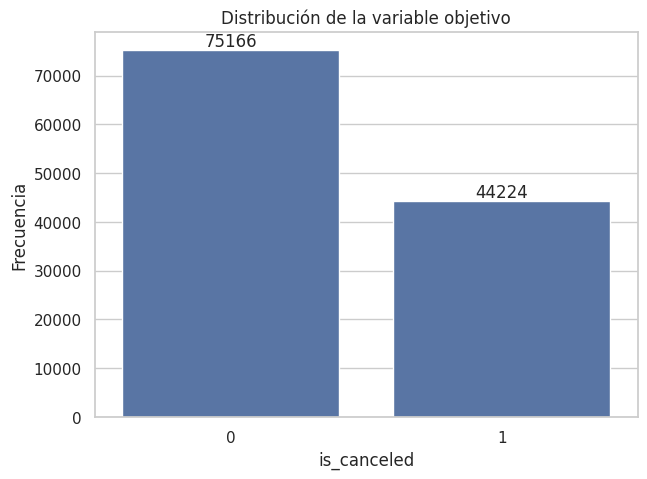

In [53]:
# Aquí grafico la variable objetivo para ver de forma más clara si hay desbalance

plt.figure(figsize=(7, 5))
ax = sns.countplot(x=df[target_col])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribución de la variable objetivo')
plt.xlabel('is_canceled')
plt.ylabel('Frecuencia')
plt.show()

In [54]:
print('Interpretación del balance de clases:')

canceladas = porcentaje[1]
no_canceladas = porcentaje[0]

print(f'{canceladas:.2f}% de las reservaciones terminan cancelándose.')
print(f'{no_canceladas:.2f}% de las reservaciones no se cancelan.')

print('El dataset no presenta un desbalance extremo, pero sí suficiente para usar F1 como métrica principal.')

Interpretación del balance de clases:
37.04% de las reservaciones terminan cancelándose.
62.96% de las reservaciones no se cancelan.
El dataset no presenta un desbalance extremo, pero sí suficiente para usar F1 como métrica principal.


## Construir un conjunto de entrenamiento y prueba

### Escoge una estrategia para construir un conjunto de entrenamiento y prueba.

### Estratifica los conjuntos por la variable dependiente.

In [55]:
# Aquí elimino variables que causarían data leakage
# reservation_status contiene el resultado final de la reservación
# reservation_status_date también ocurre después del evento

# También elimino reservation_id porque solo es un identificador

columnas_excluir = [
    'is_canceled',
    'reservation_status',
    'reservation_status_date',
    'reservation_id'
]

X = df.drop(columns=columnas_excluir)
y = df['is_canceled']

In [56]:
# company tiene demasiados valores faltantes
# por eso decido eliminarla

if 'company' in X.columns:
    X = X.drop(columns=['company'])

In [58]:
# Aquí hago la partición de entrenamiento y prueba
# Yo uso estratificación para conservar la proporción de cancelaciones en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño de entrenamiento:', X_train.shape)
print('Tamaño de prueba:', X_test.shape)

Tamaño de entrenamiento: (95512, 28)
Tamaño de prueba: (23878, 28)


In [59]:
# Aquí verifico que la estratificación sí mantuvo la distribución de clases

dist_train = y_train.value_counts(normalize=True).rename('train') * 100
dist_test = y_test.value_counts(normalize=True).rename('test') * 100

comparacion = pd.concat([dist_train, dist_test], axis=1).round(2)
display(comparacion)

,train,test
is_canceled,,
0,62.96,62.96
1,37.04,37.04


## Reportar el error de clasificación el conjunto de prueba con un modelo base. Utilizando el conjunto de prueba:

- Reporta el error de clasificación F1.
- Grafica e interpreta la matriz de confusión.
- Grafica e interpreta reporte de clasificación de precisión, recall y F1 score.
- Grafica e interpreta la curva ROC y el AUC score.

In [60]:
# Aquí identifico variables numéricas y categóricas para el preprocesamiento

numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

print('Variables numéricas:', len(numeric_features))
print('Variables categóricas:', len(categorical_features))

Variables numéricas: 18
Variables categóricas: 10


In [61]:
# Aquí construyo el preprocesamiento
# En variables numéricas imputo con mediana y escalo
# En variables categóricas imputo con la moda y convierto a variables dummy

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [62]:
# Aquí defino un modelo base sencillo
# Yo uso regresión logística porque me sirve como referencia clara y fácil de interpretar

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_proba_base)

print('F1-score del modelo base:', round(f1_base, 4))
print('ROC-AUC del modelo base:', round(auc_base, 4))

F1-score del modelo base: 0.7308
ROC-AUC del modelo base: 0.8961


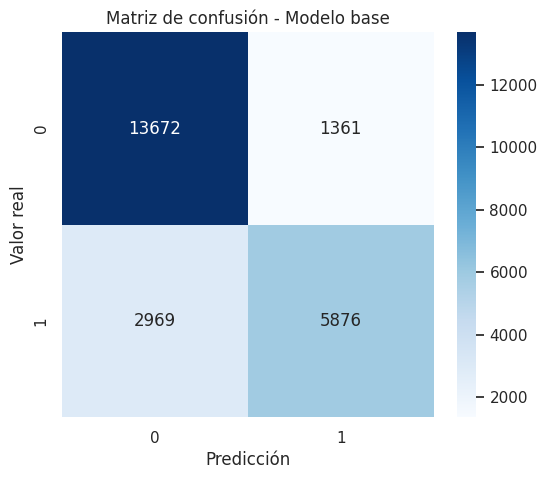

In [63]:
# Aquí grafico la matriz de confusión del modelo base

cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Modelo base')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [64]:
# Aquí muestro el classification report del modelo base en tabla
# Así lo puedo leer con más claridad

report_base = classification_report(y_test, y_pred_base, output_dict=True)
report_base_df = pd.DataFrame(report_base).transpose()

display(report_base_df.round(4))

,precision,recall,f1-score,support
0,0.8216,0.9095,0.8633,15033.0000
1,0.8119,0.6643,0.7308,8845.0000
accuracy,0.8187,0.8187,0.8187,0.8187
macro avg,0.8168,0.7869,0.7970,23878.0000
weighted avg,0.8180,0.8187,0.8142,23878.0000


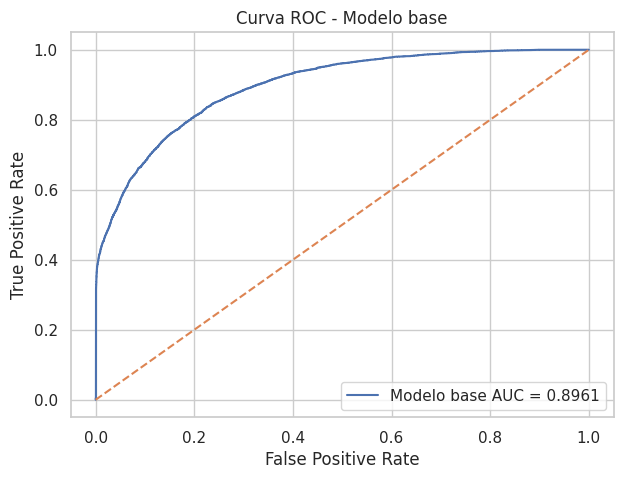

In [65]:
# Aquí grafico la curva ROC del modelo base

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f'Modelo base AUC = {auc_base:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Modelo base')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [66]:
print('Interpretación del modelo base:')

print(f'El modelo base obtuvo un F1-score de {f1_base:.3f}.')
print('Este valor representa el balance entre precisión y recall al detectar cancelaciones.')

print('Si el recall de cancelaciones es bajo, el hotel no detectaría reservaciones con riesgo de cancelación.')
print('Si la precisión es baja, el hotel podría invertir recursos en clientes que en realidad no cancelarían.')

print('Por eso el F1-score es una métrica adecuada para este problema.')

Interpretación del modelo base:
El modelo base obtuvo un F1-score de 0.731.
Este valor representa el balance entre precisión y recall al detectar cancelaciones.
Si el recall de cancelaciones es bajo, el hotel no detectaría reservaciones con riesgo de cancelación.
Si la precisión es baja, el hotel podría invertir recursos en clientes que en realidad no cancelarían.
Por eso el F1-score es una métrica adecuada para este problema.


## Producir un modelo que supere el mejor F1-score de tu modelo base en el conjunto de prueba. Considera las siguientes estrategias vistas en el modulo (no necesitas utilizar todas, solo las que consideres necesarias):

- Escoger un modelo apropiado.
- Escoger la métrica de scoring adecuada como roc_auc_score o f1.
- Escoger los hiperparámetros óptimos del modelo utilizando grid search o random search.
- Escoger el punto de corte de probabilidad adecuado utilizando el método de Discrimination Threshold.
- Ingeniería de variables: transformaciones y/o crear nuevas variables.
- Seleccionar variables: matriz de correlaciones, REFCV, quitar y poner.

In [67]:
# Aquí pruebo un modelo más fuerte que el modelo base
# Yo uso Random Forest porque puede captar relaciones más complejas
# y también suele funcionar bien cuando tengo variables numéricas y categóricas

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

# Aquí defino una búsqueda sencilla de hiperparámetros
# Yo no la hago tan grande para que sea más práctico correrla en Colab

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [10, 15, None]
}

# Aquí uso validación cruzada estratificada para conservar la proporción de clases
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Aquí busco la mejor combinación usando F1
# Yo uso F1 porque es la métrica principal del reto

grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print('Mejores hiperparámetros:')
print(grid.best_params_)

Mejores hiperparámetros:
{'model__max_depth': None, 'model__n_estimators': 300}


In [68]:
# Aquí evalúo el mejor modelo encontrado con GridSearch
# Primero obtengo probabilidades y después la clasificación final

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

f1_final = f1_score(y_test, y_pred)
auc_final = roc_auc_score(y_test, y_prob)

print('F1 modelo base:', round(f1_base, 4))
print('F1 modelo mejorado:', round(f1_final, 4))
print('ROC-AUC modelo mejorado:', round(auc_final, 4))

F1 modelo base: 0.7308
F1 modelo mejorado: 0.8503
ROC-AUC modelo mejorado: 0.959


## Evaluar e interpretar los resultados del mejor modelo en el conjunto de prueba, tienes que reportar un modelo con un F1-score superior e interpretar los siguientes resultados.

(Recuerda que obtener un F1 score más alto, implica reducir el error de generalización)

- Reporta el error de clasificación F1.
- Grafica e interpreta la matriz de confusión.
- Grafica e interpreta reporte de clasificación de precisión, recall y F1 score.
- Grafica e interpreta la curva ROC y el AUC score.

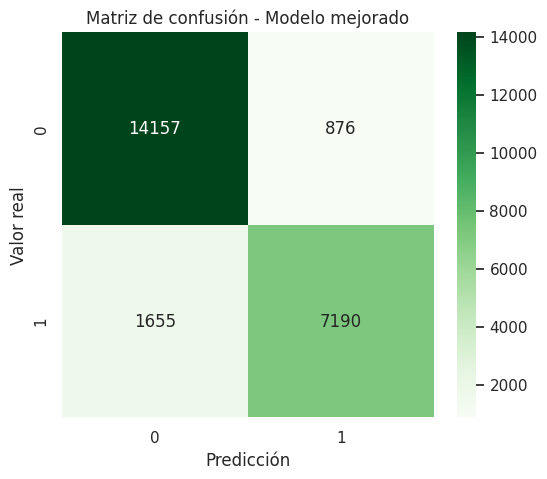

In [69]:
# Aquí grafico la matriz de confusión del modelo mejorado
# Yo la reviso para entender en qué tipo de error se equivoca más el modelo

cm_final = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')

plt.title('Matriz de confusión - Modelo mejorado')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [70]:
# Aquí muestro el reporte de clasificación del modelo mejorado
# Así puedo revisar precisión, recall y F1 de cada clase

report_final = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report_final).transpose().round(4)

,precision,recall,f1-score,support
0,0.8953,0.9417,0.9179,15033.000
1,0.8914,0.8129,0.8503,8845.000
accuracy,0.8940,0.8940,0.8940,0.894
macro avg,0.8934,0.8773,0.8841,23878.000
weighted avg,0.8939,0.8940,0.8929,23878.000


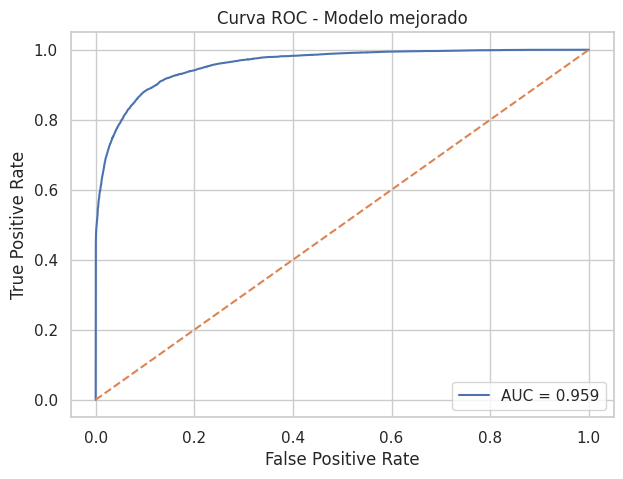

In [71]:
# Aquí grafico la curva ROC del modelo mejorado
# Yo la uso para revisar qué tan bien separa el modelo ambas clases

fpr_final, tpr_final, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_final, tpr_final, label=f'AUC = {auc_final:.3f}')
plt.plot([0, 1], [0, 1], '--')

plt.title('Curva ROC - Modelo mejorado')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [72]:
# Aquí interpreto el desempeño del mejor modelo
# Yo comparo sus resultados contra el modelo base para justificar la mejora

print('Interpretación del modelo mejorado:')

print(f'El modelo mejorado obtuvo un F1-score de {f1_final:.3f}, mientras que el modelo base obtuvo {f1_base:.3f}.')

if f1_final > f1_base:
    print('Esto me indica que sí hubo una mejora real en la capacidad del modelo para detectar cancelaciones.')
else:
    print('Esto me indica que la mejora no fue suficiente y tendría que revisar más ajustes.')

print(f'El ROC-AUC del modelo mejorado fue {auc_final:.3f}, lo que me ayuda a evaluar qué tan bien separa el modelo las reservaciones que sí cancelan de las que no cancelan.')

print('En la matriz de confusión me enfoco sobre todo en los falsos negativos, porque son casos donde una reservación sí iba a cancelarse pero el modelo no la detectó.')

print('Ese error es importante para el negocio porque limita la posibilidad de actuar a tiempo con estrategias de retención o con ajustes de ocupación.')

print('También reviso los falsos positivos, porque si fueran demasiados el hotel podría dedicar esfuerzos a reservaciones que realmente no tenían alto riesgo de cancelación.')

print('En conjunto, el modelo mejorado resulta más útil si aumenta la detección de cancelaciones sin deteriorar demasiado la precisión.')

Interpretación del modelo mejorado:
El modelo mejorado obtuvo un F1-score de 0.850, mientras que el modelo base obtuvo 0.731.
Esto me indica que sí hubo una mejora real en la capacidad del modelo para detectar cancelaciones.
El ROC-AUC del modelo mejorado fue 0.959, lo que me ayuda a evaluar qué tan bien separa el modelo las reservaciones que sí cancelan de las que no cancelan.
En la matriz de confusión me enfoco sobre todo en los falsos negativos, porque son casos donde una reservación sí iba a cancelarse pero el modelo no la detectó.
Ese error es importante para el negocio porque limita la posibilidad de actuar a tiempo con estrategias de retención o con ajustes de ocupación.
También reviso los falsos positivos, porque si fueran demasiados el hotel podría dedicar esfuerzos a reservaciones que realmente no tenían alto riesgo de cancelación.
En conjunto, el modelo mejorado resulta más útil si aumenta la detección de cancelaciones sin deteriorar demasiado la precisión.


## Justifica tus decisiones e interpretar los resultados en el conjunto de prueba, en el contexto del negocio.

### Cómo tu modelo y tus entregables ayudarán al negocio a evitar que los clientes de la cadena hotelera cancelen sus reservaciones.

In [78]:
# Aquí justifico las decisiones que tomé durante el modelado
# Yo explico por qué usé ciertas variables, métricas y modelos

print('Justificación de decisiones:')

print('Primero elegí is_canceled como variable objetivo porque representa directamente el evento que el hotel quiere anticipar.')

print('En este sentido, eliminé reservation_status y reservation_status_date porque contienen información posterior al resultado y eso habría generado data leakage.')

print('De igual forma, eliminé reservation_id del modelo porque solo es un identificador y no representa una característica real para predecir cancelaciones.')

print('Además eliminé company porque tiene demasiados valores faltantes y eso la vuelve poco útil en este ejercicio.')

print('Implementé una partición estratificada para conservar la proporción de cancelaciones en entrenamiento y prueba.')

print('Tomé F1 como métrica principal porque necesito balancear precisión y recall, especialmente en la detección de la clase cancelada.')

print('Primero usé una regresión logística como modelo base para tener una referencia simple y clara.')

print('Después probé Random Forest porque puede capturar relaciones no lineales y suele funcionar mejor en datos de este tipo.')

print('Finalmente usé GridSearchCV con scoring igual a F1 para buscar la mejor combinación de hiperparámetros de acuerdo con el objetivo del reto.')

Justificación de decisiones:
Primero elegí is_canceled como variable objetivo porque representa directamente el evento que el hotel quiere anticipar.
En este sentido, eliminé reservation_status y reservation_status_date porque contienen información posterior al resultado y eso habría generado data leakage.
De igual forma, eliminé reservation_id del modelo porque solo es un identificador y no representa una característica real para predecir cancelaciones.
Además eliminé company porque tiene demasiados valores faltantes y eso la vuelve poco útil en este ejercicio.
Implementé una partición estratificada para conservar la proporción de cancelaciones en entrenamiento y prueba.
Tomé F1 como métrica principal porque necesito balancear precisión y recall, especialmente en la detección de la clase cancelada.
Primero usé una regresión logística como modelo base para tener una referencia simple y clara.
Después probé Random Forest porque puede capturar relaciones no lineales y suele funcionar mej

In [76]:
# Aquí conecto los resultados del modelo con decisiones útiles para el negocio
# Yo trato de aterrizar el análisis a acciones concretas para el hotel

print('Recomendaciones para el negocio:')

print('Recomiendo usar la probabilidad de cancelación para clasificar las reservaciones en niveles de riesgo bajo, medio y alto.')

print('Las reservaciones con mayor probabilidad de cancelación pueden recibir recordatorios, seguimiento comercial o incentivos para reducir la probabilidad de cancelación.')

print('El hotel también puede usar estas probabilidades para mejorar su planeación de ocupación y reducir el impacto de cancelaciones de último momento.')

print('Si ciertas variables como lead_time, tipo de depósito o segmento de mercado aparecen relacionadas con más cancelaciones, el negocio puede enfocar acciones específicas en esos perfiles.')

print('La principal ventaja de este modelo es que no solo clasifica, sino que también entrega probabilidades, y eso ayuda a priorizar mejor los esfuerzos.')

Recomendaciones para el negocio:
Recomiendo usar la probabilidad de cancelación para clasificar las reservaciones en niveles de riesgo bajo, medio y alto.
Las reservaciones con mayor probabilidad de cancelación pueden recibir recordatorios, seguimiento comercial o incentivos para reducir la probabilidad de cancelación.
El hotel también puede usar estas probabilidades para mejorar su planeación de ocupación y reducir el impacto de cancelaciones de último momento.
Si ciertas variables como lead_time, tipo de depósito o segmento de mercado aparecen relacionadas con más cancelaciones, el negocio puede enfocar acciones específicas en esos perfiles.
La principal ventaja de este modelo es que no solo clasifica, sino que también entrega probabilidades, y eso ayuda a priorizar mejor los esfuerzos.


In [77]:
# Aquí cierro el ejercicio con una conclusión breve basada en los resultados
# Yo resumo el valor técnico y el valor de negocio del modelo

print('Conclusión:')

print('Construí un flujo de clasificación binaria para predecir cancelaciones de reservaciones hoteleras.')

print('Primero entrené un modelo base y después lo comparé contra un modelo mejorado para verificar si realmente había una mejora en F1.')

print('La mejora del modelo no se debe a fuga de información, sino a una mejor elección del algoritmo y a la búsqueda de hiperparámetros con GridSearchCV.')

print('En términos de negocio, este modelo puede ayudar a anticipar cancelaciones, priorizar acciones de retención y tomar mejores decisiones de ocupación.')

Conclusión:
Construí un flujo de clasificación binaria para predecir cancelaciones de reservaciones hoteleras.
Primero entrené un modelo base y después lo comparé contra un modelo mejorado para verificar si realmente había una mejora en F1.
La mejora del modelo no se debe a fuga de información, sino a una mejor elección del algoritmo y a la búsqueda de hiperparámetros con GridSearchCV.
En términos de negocio, este modelo puede ayudar a anticipar cancelaciones, priorizar acciones de retención y tomar mejores decisiones de ocupación.


## Genera un CSV con todos los datos de reservaciones que incluya solo tres columnas el id de la reservación, la probabilidad de cancelación y la clasificación de cancelación (0 ó 1), que Juan le va a entregar a Belén.

In [79]:
# Aquí genero las predicciones para todo el dataset
# Yo aplico la misma limpieza que usé en el entrenamiento para no romper la consistencia

X_full = df.drop(columns=[
    'is_canceled',
    'reservation_status',
    'reservation_status_date',
    'reservation_id'
])

# Aquí vuelvo a eliminar company porque tampoco la usé para entrenar el modelo
if 'company' in X_full.columns:
    X_full = X_full.drop(columns=['company'])

# Aquí obtengo la probabilidad de cancelación y la clasificación final
proba = best_model.predict_proba(X_full)[:, 1]
pred = best_model.predict(X_full)

csv_final = pd.DataFrame({
    'reservation_id': df['reservation_id'],
    'probabilidad_cancelacion': proba,
    'clasificacion_cancelacion': pred
})

csv_final.head()

,reservation_id,probabilidad_cancelacion,clasificacion_cancelacion
0,1,0.050000,0
1,2,0.040000,0
2,3,0.033333,0
3,4,0.026667,0
4,5,0.043333,0


In [80]:
# Aquí exporto el archivo final que pide el reto

csv_final.to_csv('predicciones_hoteles.csv', index=False)

print('Archivo generado: predicciones_hoteles.csv')

Archivo generado: predicciones_hoteles.csv


In [81]:
# Aquí hago una revisión rápida del archivo final
# Yo verifico que tenga las tres columnas correctas y que sí existan ambas clases

print('Columnas del archivo final:')
print(csv_final.columns.tolist())

print('\nDistribución de la clasificación final:')
print(csv_final['clasificacion_cancelacion'].value_counts())

print('\nResumen de probabilidades:')
print(csv_final['probabilidad_cancelacion'].describe())

Columnas del archivo final:
['reservation_id', 'probabilidad_cancelacion', 'clasificacion_cancelacion']

Distribución de la clasificación final:
clasificacion_cancelacion
0    75848
1    43542
Name: count, dtype: int64

Resumen de probabilidades:
count    119390.000000
mean          0.373815
std           0.415271
min           0.000000
25%           0.020000
50%           0.110000
75%           0.870000
max           1.000000
Name: probabilidad_cancelacion, dtype: float64


In [82]:
from google.colab import files
files.download('predicciones_hoteles.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>